### References

- **SpinPulse**, B. Vermersch *et al.*, *The SpinPulse library for transpilation and noise-accurate simulation of spin qubit quantum computers*, [arXiv:2601.10435](https://arxiv.org/abs/2601.10435). Source of the noise model used here (their Sec. 3.4): noise types, Ramsey contrast, and the quantum-channel formulation.
- **Non-Markovian QEC**, O. Gravier *et al.*, *Simulated non-Markovian Noise Resilience of Silicon-Based Spin Qubits with Surface Code Error Correction*, [arXiv:2507.08713](https://arxiv.org/abs/2507.08713). The underlying hardware noise model, and the $T_2^*(t_m)$ dependence reproduced below.
- **FDSOI platform**, B. C. Paz *et al.*, *FDSOI platform for quantum computing*, IEDM 2025, [IEEE 10873521](https://ieeexplore.ieee.org/document/10873521). Source of the target numbers: $T_2^* \approx 500$ ns without echo, $T_2^{\text{echo}} \approx 40\,\mu$s with Hahn echo.

# Decoherence of a single spin qubit

We simulate the effect of slow noise on a single electron spin qubit, using a classical approximation of the stochastic environmental influence rather than a full quantum mechanical treatment of the bath.

## Physical setup

One electron confined in a quantum dot, precessing in a static magnetic field. We work in the frame rotating at the *reference* Larmor frequency $\omega_r$ fixed by the control electronics, so the Hamiltonian keeps only the deviation:

$$H(t) = \frac{\delta\omega(t)}{2}\,\sigma_z, \qquad \delta\omega(t) = \omega_L(t) - \omega_r\,,$$

which is the mismatch between where the qubit actually is and where the experiment *thinks* it is. This is pure dephasing since the Hamiltoniain is proportional to $\sigma_z$: nothing flips the spin, only the precession rate is uncertain. This is justified here since $T_1$ is 2–3 orders of magnitude longer than $T_2^*$ in Si spin qubits(see SpinPulse ref below).

Since $H(t) \propto \sigma_z$, the Hamiltonians at different times commute, the time ordering is trivial, and the evolution is exact and unitary:

$$U(t) = \exp\left(-i\,\frac{\phi(t)}{2}\,\sigma_z\right), \qquad \phi(t) = \int_0^t \delta\omega(t')\,dt'$$

The whole physics of one realisation is carried by the single scalar $\phi(t)$. $U$ puts a relative phase between $|0\rangle$ and $|1\rangle$, i.e. $|+\rangle$ rotates on the equator of the Bloch sphere by $\phi$. *(This stops being true as soon as a drive field on $\sigma_x/\sigma_y$ is added )*

Evolution of the density matrix is given by $$\rho(t)=U\rho_0U^{\dagger}=\tfrac12\begin{pmatrix}1 & e^{-i\phi(t)}\\
e^{i\phi(t)} &1\end{pmatrix}\,.$$

## Ensemble averaging and loss of coherence

Each run evolves unitarily. Decoherence arises only from the ensemble average. This is what a Ramsey measurement does: it is destructive and gives one bit, so the experimentalist repeats the sequence thousands of times, and between repetitions the environment has moved on. The measured curve *is* an average over realisations of the environment.

Since $\rho$ depends on the noise only through $e^{-i\phi}$, the average acts on that factor alone and we have the Ramsey contrast

$$C(t) = \mathbb{E}\left[e^{-i\phi(t)}\right]$$

Populations stay pinned at $1/2$ (pure dephasing), only the off-diagonal decays, and the whole decoherence is carried by that single complex number:

$$\rho(t) = \frac{1}{2}\begin{pmatrix} 1 & C \\ C^* & 1\end{pmatrix} \qquad \Longleftrightarrow \qquad \mathcal{E}(\rho) = \frac{1+C}{2}\,\rho + \frac{1-C}{2}\,Z\rho Z$$

which is a $\sigma_z$-dephasing channel with phase-flip probability $p = (1-C)/2$. We then measure $\langle\sigma_x\rangle = \mathrm{Re}\,C(t)$: the oscillation carries the detuning (deterministic, calibratable) and the envelope $|C|$ carries the decoherence (statistical, not calibratable). The quasi-static case has an analytic reference to check the numerics against.

## The noise models

We compare two noise models. Note that both are Gaussian processes (the amplitude of $\delta\omega(t)$ at each time step $t$ is Gaussian distributed) what distinguishes them is the correlation in time of the noise, so the power spectrum.

| | spectrum | correlation | contrast $C(t)$ |
|---|---|---|---|
| **quasi-static** | $\delta(f)$ | frozen during a run | $\exp(-\sigma^2t^2/2)$, so $T_2^* = \sqrt{2}/\sigma$ |
| **1/f (pink)** | $S_0/f$ | slow drift | $\approx \exp(-t^2/T_2^*(t)^2)$, log-dependent $T_2^*$ |
| **white** | constant | none (Markovian) | $\exp(-t\sigma^2/2)$ — *exponential* |

1. **Quasi-static noise**: $\delta\omega$ frozen during each run, redrawn between runs (perfectly correlated in time). The idealisation of a noise that varies very slowly in time (non-Markovian).
2. **1/f (pink) noise**: slow fluctuations carry more power than fast ones (partially correlated). Physically this is the collective effect of many two-level fluctuators at the Si/SiO$_2$ interfaces and of the residual $^{29}$Si nuclear spin bath. This is the realistic case, and the reason the noise is non-Markovian.
3. **White noise** is kept as a control: the uncorrelated limit, the only Markovian one of the three, and the only one giving exponential rather than Gaussian decay.
   
### Parameterising 1/f signal with $S_0$

The three rows are not on the same footing. Since the power spectrum describes how the variance of $\delta\omega$ is distributed across frequencies, the total variance is its integral (Parseval), which for a 1/f spectrum reads

$$\sigma^2 = \int_{f_{\min}}^{f_{\max}} \frac{S_0}{f}\,df = S_0 \ln\!\left(\frac{f_{\max}}{f_{\min}}\right)$$

and diverges logarithmically as $f_{\min}\to 0$. There is thus no variance of 1/f noise as such, only a variance within a given bandwidth: the noise carries equal power per octave and has no characteristic timescale, so each additional decade of observation adds the same amount. The spectral density $S_0$ is by contrast a property of the device, independent of the measurement window, and is the quantity experimentalists report. The generator therefore takes $S_0$ with the two cutoffs and computes the variance from the relation above (`var_target`).

This choice is not cosmetic. The infrared cutoff is set by the total acquisition time, $f_{\min} = 1/t_m$, so at fixed $S_0$ a longer acquisition increases $\sigma$ and shortens $T_2^*$; this is the effect reproduced further down, and it would have been invisible had we parameterised by $\sigma$ directly. Following Gravier *et al.*, the coherence time follows from

$$T_2^*(t) = \frac{1}{2\pi\sqrt{S_0\,\ln\!\left(1/(f_{\min}t)\right)}}$$

inverted in `S0_from_T2star` to match the 500 ns of the IEDM device. The relation is implicit in $T_2^*$, so inverting it at a single point is approximate, and the measured value comes out somewhat longer than the target.

*(Convention note: Gravier et al. quote the fidelity $F(t) = \langle+|\rho(t)|+\rangle = \tfrac{1}{2}(1+C(t))$ rather than the contrast itself)*

In [1]:
import numpy as np
import matplotlib as mpl
mpl.rcdefaults()
import matplotlib.pyplot as plt

# for reproducibility of results purposes : the list of random numbers becomes the same each time I run the notebook.
rng = np.random.default_rng(42)

# Units ( hbar = 1)
# work in microseconds us and rad/us for angular frequencies, so numbers can be compared to the Quobly 2025 paper.
t_s = 1e-3            # sampling time: 1 ns expressed in us. Sets the time resolution of the simulation.
T_max = 2.0           # duration of the simulation (us)
Nt = int(T_max / t_s) #number of simulated points for each relization
tlist = np.arange(Nt) * t_s #list of time points
dt = tlist[1] - tlist[0] #time interval between each updated-evolution of the state

# Qubit parameters
# Note : I work in the frame rotating at the reference Larmor frequency (SpinPulse  Eq.1)
# What is left is a detuning, i.e. how far the experience deliberately shifts the qubit from the reference (this has important
# consequence to isolate experimentally the loss of coherence, I think).
detuning = 2*np.pi * 5.0    # rad/us (5 MHz),to see Ramsey fringes. Set to 0 to plot the envelope.
# detuning chosen so that a few fringes fit within T2*, purely for readability of the first figure


# Noise amplitude, calibrated on the electron spin qubit of the IEDM paper (T2* ~ 500ns without echo)
T2_star = 0.5                        
sigma_noise = np.sqrt(2) / T2_star   # rad/us. For quasi-static noise T2* = sqrt(2)/sigma, so I invert that relation.
N_samples = 2000      # ensemble size, independant realisations of the environment, producing slightly different qubit evolution
                      #In the limit N_samples goes to infinity, we would recover exact ensemble average

# Pauli operators
id2 = np.eye(2, dtype=complex) 
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)

# |+x> initial state
psi0 = np.array([1, 1], dtype=complex) / np.sqrt(2)
rho0 = np.outer(psi0, psi0.conj())

In [2]:
##1. Gaussian noise ensamble average: average distribution of the density matrix if the noise is Gaussian close to qubit frequency.
# Instead of solving a master equation I now return directly the accumulated phases phi(t) of each realisation,
# because in the rotating frame H(t) is always proportional to sz, so the evolution is a pure phase.
def quasistatic_phases(tlist, N_samples, sigma_noise, detuning=0.0, rng=rng):
    delta_omega = rng.normal(0.0, sigma_noise, size=(N_samples, 1)) ##omega noise from a gaussian distribution, one draw per run
    return (detuning + delta_omega) * tlist[None, :]                ##phi(t) = (omega + delta_omega)*t since the noise is frozen

In [3]:
## 2. 1/f slow noise generator, now parameterised by the spectral intensity S0 as in SpinPulse
# eps(t) = 2*pi*sqrt(S0)*g(t), with g of power spectrum 1/f between f_min and the Nyquist frequency.
# Two things changed w.r.t. my first version, and both were needed:
#  - I build a one-sided (hermitian) spectrum with rfft/irfft, instead of filtering a full complex
#    spectrum and taking .real, which was breaking the symmetry and losing control of the variance.
#  - the DC coefficient is set to zero and f_min is a real physical cutoff: a constant offset of the
#    Larmor frequency is a calibration error, not noise, and my old freqs[0]=1e-6 was injecting a
#    random static detuning ~700x larger than the first genuine mode.
def generate_1overf_noise(Nt, S0, dt, f_min=None, rng=rng):
    freqs = np.fft.rfftfreq(Nt, d=dt) #one-sided array of frequencies
    if f_min is None:
        f_min = 1.0 / (Nt * dt) #by default the IR cutoff is set by the duration of the trace itself

    amp = np.zeros_like(freqs) #array of zeros, one per freq
    keep=freqs >= f_min
    amp[keep] = 1.0 / np.sqrt(freqs[keep]) ## to obtain a power spectrum S(f)~|A(f)|^2~1/f for all frequencies greater than
    # the minimum frequency

    coeffs = (rng.standard_normal(freqs.size) + 1j*rng.standard_normal(freqs.size)) / np.sqrt(2) #white Gnoise
    coeffs = coeffs * amp
    coeffs[0] = 0.0 #no DC component

    noise = np.fft.irfft(coeffs, n=Nt) ##inverse Fourier transform to recreate a temporal signal

    # final normalisation, but now against a target variance I know analytically:
    # integrating S0/f between the two cutoffs gives var = (2*pi)^2 * S0 * ln(f_max/f_min).
    var_target = (2*np.pi)**2 * S0 * np.log(freqs[-1] / f_min)
    return noise / np.std(noise) * np.sqrt(var_target)

In [4]:
## 3. White noise: the uncorrelated limit, kept as a control case. eps(t) is drawn independently at each time step, so the environment has no memory at all. 
# This is the only Markovian case of the three,so the only one where a Lindblad master equation would have been
# legitimate. Their Eq.(27) gives C(t) = exp(-t*sigma^2/2), namely exponential decay and not Gaussian.
def white_phases(tlist, N_samples, sigma_noise, detuning=0.0, rng=rng):
    dt = tlist[1] - tlist[0]
    eps = rng.normal(0.0, sigma_noise, size=(N_samples, len(tlist))) #one independent draw per time step
    return detuning * tlist[None, :] + np.cumsum(eps, axis=1) * dt

In [5]:
# Choosing S0 to hit a target T2*, by inverting T2*(t) = 1/(2*pi*sqrt(S0*ln(1/(f_min*t)))) at t = T2*.
def S0_from_T2star(T2_star, f_min):
    return 1.0 / (2*np.pi**2 * T2_star**2 * np.log(1.0/(f_min*T2_star)))

In [6]:
##generate the accumulated phases of N_samples realisations with 1/f noise.
# Change of construction here. Before, I drew one independent short trace per realisation, with f_min = 1/T_max: the lowest mode was then 
#  a single sinusoid of period exactly the observation window, and since the 1/f weighting makes that mode dominate, its integral came back to zero at
# t = T_max -> spurious revival of the contrast, and a T2* twice too long. Now I generate onee long trace of duration t_m ("machine time") and slide the experiment window
# along it, which is both the correct numerics (f_min << 1/T_max) and what actually happens in the
# lab: there is a single environment evolving continuously, and successive repetitions of the Ramsey sequence sample successive windows of it.
def onef_phases(tlist, N_samples, S0, detuning=0.0, t_m=None, rng=rng):
    Nt = len(tlist)
    dt = tlist[1] - tlist[0]

    if t_m is None:
        t_m = N_samples * Nt * dt #back-to-back repetitions, as in a real acquisition
    Nt_total = int(round(t_m / dt))
    f_min = 1.0 / t_m

    trace = generate_1overf_noise(Nt_total, S0, dt, f_min=f_min, rng=rng)

    # one window per realisation, each experiment starting with a fresh phase phi(0) = 0
    stride = (Nt_total - Nt) // N_samples #
    starts = np.arange(N_samples) * stride # starting index of each window
    windows = np.empty((N_samples, Nt))
    for k in range(N_samples):
        windows[k] = trace[starts[k] : starts[k] + Nt]

    return detuning * tlist[None, :] + np.cumsum(windows, axis=1) * dt

# rho(t) of the average channel E(rho) = E[U rho0 U^dag], for rho0 = |+><+|.
# Averaging exp(-i phi) over the ensemble is exactly what they call the Ramsey contrast C(t),
# so the whole decoherence is carried by that single complex number at each time.
def rho_from_phases(phases):
    C = np.exp(-1j * phases).mean(axis=0)
    rho = np.zeros((phases.shape[1], 2, 2), dtype=complex)
    rho[:, 0, 0] = rho[:, 1, 1] = 0.5      #populations stay at 1/2, pure dephasing does not touch them
    rho[:, 0, 1] = 0.5 * C                 #the coherence is what decays
    rho[:, 1, 0] = 0.5 * np.conj(C)
    return rho

In [7]:
#<sigma_x>(t) from a computed density matrix
def expectation_sigma_x(rho_t):
    return np.real(np.einsum('ij,tji->t', sx, rho_t))

In [8]:
# Contrast and fitting, so that T2* becomes something I MEASURE rather than something I impose.
# Up to now I chose S0 so that T2* came out at 500ns and then checked that it did, which is circular.
def ramsey_contrast(phases):
    return np.abs(np.exp(-1j * phases).mean(axis=0)) #the envelope, i.e. |C(t)|

from scipy.optimize import curve_fit

def fit_T2_gaussian(tlist, C):
    # Gaussian decay exp(-(t/T2)^2), which is what correlated noise gives (their Eq.26 and Eq.28).
    # I only fit where C is between 0.1 and 1 : below that I am fitting the Monte Carlo floor (~1/sqrt(N)).
    mask = C > 0.1
    f = lambda t, T2: np.exp(-(t/T2)**2)
    popt, _ = curve_fit(f, tlist[mask], C[mask], p0=[T2_star])
    return popt[0]
def fit_T2_exponential(tlist, C):
    # Exponential decay exp(-t/T2), which is what UNcorrelated (Markovian) noise gives (their Eq.27).
    mask = C > 0.1
    f = lambda t, T2: np.exp(-t/T2)
    popt, _ = curve_fit(f, tlist[mask], C[mask], p0=[T2_star])
    return popt[0]

In [9]:
# Gaussian quasi-static
rho_quasistatic = rho_from_phases(quasistatic_phases(tlist, N_samples, sigma_noise, detuning))
sx_quasistatic = expectation_sigma_x(rho_quasistatic)

# 1/f noise
t_m = N_samples * T_max          # 4 ms of machine time for 2000 repetitions of a 2 us sequence
S0 = S0_from_T2star(T2_star, 1.0/t_m)
rho_1overf = rho_from_phases(onef_phases(tlist, N_samples, S0, detuning, t_m=t_m))
sx_1overf = expectation_sigma_x(rho_1overf)

# Analytic reference for Gaussian quasi-static : C(t) = exp(-sigma^2 t^2 /2), which is their Eq.(26)
sx_analytic = np.cos(detuning * tlist) * np.exp(-0.5 * sigma_noise**2 * tlist**2)

C_pink = np.abs(np.exp(-1j * onef_phases(tlist, N_samples, S0, 0.0, t_m=t_m)).mean(axis=0))
i_e_pink = np.argmin(np.abs(C_pink - np.exp(-1.0)))
print(f"pink: T2* targeted = {T2_star*1e3:.0f} ns   |   T2* measured = {tlist[i_e_pink]*1e3:.0f} ns")

pink: T2* targeted = 500 ns   |   T2* measured = 535 ns


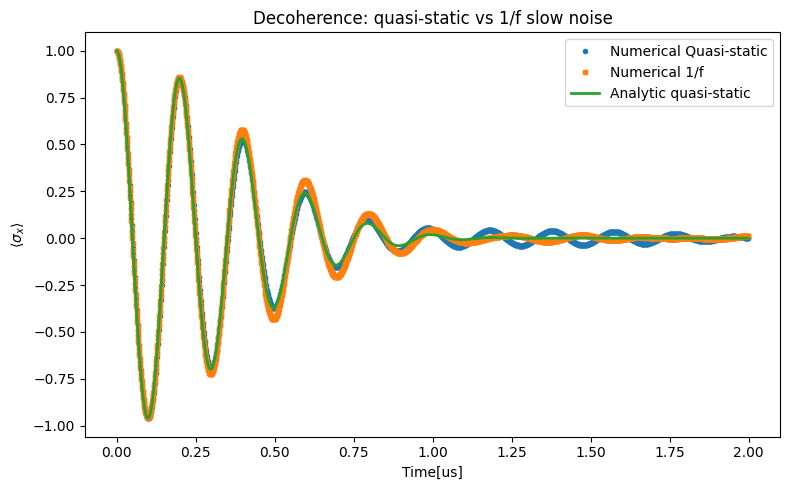

In [10]:
plt.figure(figsize=(8,5))
plt.plot(tlist, sx_quasistatic, 'o', markersize=3, label='Numerical Quasi-static')
plt.plot(tlist, sx_1overf, 's', markersize=3, label='Numerical 1/f')
plt.plot(tlist, sx_analytic, '-', linewidth=2, label='Analytic quasi-static')
plt.xlabel('Time[us]')
plt.ylabel(r'$\langle \sigma_x \rangle$')
plt.title('Decoherence: quasi-static vs 1/f slow noise')
plt.legend()
plt.tight_layout()
plt.show()

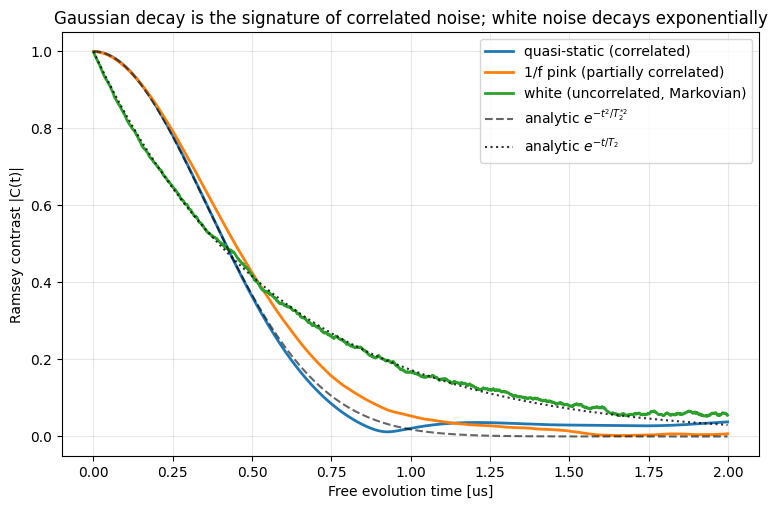

Gaussian fit residual, quasi-static : 0.038
Gaussian fit residual, white        : 0.186


In [11]:
# Contrast for the three noise types, on the same axes. Detuning set to 0 to get the envelopes only.
# This is the same object as their Fig.2 d)-f).
# NB on the white case: I pick sigma so that the decay is visible on the same window, not so that T2*
# matches, with zero correlation time the two are not comparable at fixed sigma. Also, discrete white noise has a sigma that depends on dt 
#(the physical quantity is the spectral density sigma^2*dt), so this curve is a demonstration of the SHAPE, not a calibrated coherence time.
C_qs = ramsey_contrast(quasistatic_phases(tlist, N_samples, sigma_noise, 0.0))
C_1f = ramsey_contrast(onef_phases(tlist, N_samples, S0, 0.0, t_m=t_m))
C_wh = ramsey_contrast(white_phases(tlist, N_samples, 60.0, 0.0))

plt.figure(figsize=(9,5.5))
plt.plot(tlist, C_qs, linewidth=2, label='quasi-static (correlated)')
plt.plot(tlist, C_1f, linewidth=2, label='1/f pink (partially correlated)')
plt.plot(tlist, C_wh, linewidth=2, label='white (uncorrelated, Markovian)')

# the two analytic shapes, to make the Gaussian vs exponential distinction explicit
T2_wh = fit_T2_exponential(tlist, C_wh)
plt.plot(tlist, np.exp(-0.5*(sigma_noise*tlist)**2), 'k--', alpha=0.6, label=r'analytic $e^{-t^2/T_2^{*2}}$')
plt.plot(tlist, np.exp(-tlist/T2_wh), 'k:', alpha=0.8, label=r'analytic $e^{-t/T_2}$')

plt.xlabel('Free evolution time [us]')
plt.ylabel('Ramsey contrast |C(t)|')
plt.title('Gaussian decay is the signature of correlated noise; white noise decays exponentially')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Gaussian fit residual, quasi-static : {np.abs(C_qs - np.exp(-(tlist/fit_T2_gaussian(tlist,C_qs))**2)).max():.3f}")
print(f"Gaussian fit residual, white        : {np.abs(C_wh - np.exp(-(tlist/fit_T2_gaussian(tlist,C_wh))**2)).max():.3f}")

t_m =     0.10 ms   ->   T2* =    701 +/- 58 ns
t_m =     0.40 ms   ->   T2* =    603 +/- 21 ns
t_m =     1.60 ms   ->   T2* =    547 +/- 9 ns
t_m =     6.40 ms   ->   T2* =    522 +/- 17 ns
t_m =    25.60 ms   ->   T2* =    456 +/- 13 ns
t_m =   102.40 ms   ->   T2* =    436 +/- 10 ns


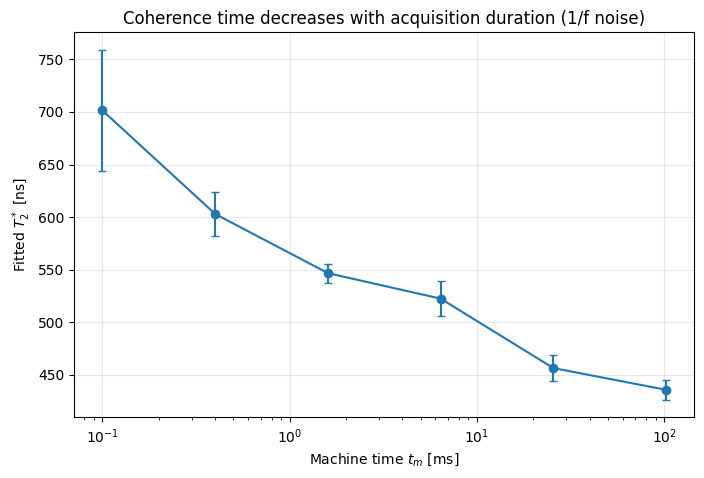

In [12]:
# T2* vs machine time. This is the result I find the most telling: with 1/f noise there is no low
# frequency plateau, so the longer the acquisition, the lower the frequencies that get included, the
# larger the phase spread, and the SHORTER the apparent coherence time. T2* is therefore not a property
# of the device alone, it also depends on how long the experiment ran.
# A Markovian (white) noise would show no such dependence at all, so this is a direct signature of the
# non-Markovian character. Their Appendix C (Fig C.2) fits it by T2* = 1/(2*pi*sqrt(S0*(ln(t_m) - C))).

S0_fixed = S0_from_T2star(T2_star, 1.0/(N_samples*T_max)) #S0 is FIXED here, only t_m varies
t_m_list = np.array([0.025, 0.1, 0.4, 1.6, 6.4, 25.6]) * N_samples * T_max

# The predicted dependence is logarithmic, so a large change in t_m moves T2* by very little: over
# this range ln(t_m) grows by a factor ~2, so T2* should fall by only ~sqrt(2). That is close to my
# Monte Carlo floor (the contrast is an average over N_samples draws, so it is known to ~1/sqrt(N) ~ 2%, which propagates to a few percent on the fitted T2*). I therefore repeat each point a few
# times and keep the scatter as an error bar, rather than reading a trend off single runs.
n_rep = 3
T2_all = np.zeros((len(t_m_list), n_rep))

for i, t_m in enumerate(t_m_list):
    for r in range(n_rep):
        phases = onef_phases(tlist, N_samples, S0_fixed, detuning=0.0, t_m=t_m)
        T2_all[i, r] = fit_T2_gaussian(tlist, ramsey_contrast(phases))

T2_mean = T2_all.mean(axis=1)
T2_err = T2_all.std(axis=1) / np.sqrt(n_rep)

for t_m, T2, e in zip(t_m_list, T2_mean, T2_err):
    print(f"t_m = {t_m*1e-3:8.2f} ms   ->   T2* = {T2*1e3:6.0f} +/- {e*1e3:.0f} ns")

plt.figure(figsize=(8,5))
plt.errorbar(t_m_list*1e-3, T2_mean*1e3, yerr=T2_err*1e3, fmt='o-', capsize=3)
plt.xscale('log')
plt.xlabel('Machine time $t_m$ [ms]')
plt.ylabel('Fitted $T_2^*$ [ns]')
plt.title('Coherence time decreases with acquisition duration (1/f noise)')
plt.grid(True, alpha=0.3)
plt.show()

# # Linearised form: squaring and inverting the analytic relation gives
# #   1/T2*^2 = 4*pi^2*S0*(ln(t_m) - C)
# # so 1/T2*^2 vs ln(t_m) should be a STRAIGHT LINE of slope 4*pi^2*S0. This is a much stronger test
# # than eyeballing a curve: the slope is a number I can compare to the S0 I injected.
# x = np.log(t_m_list)
# y = 1.0 / T2_mean**2
# y_err = 2 * T2_err / T2_mean**3
# slope, intercept = np.polyfit(x, y, 1)
# print(f"\nfitted slope = {slope:.4f}   |   expected 4*pi^2*S0 = {4*np.pi**2*S0_fixed:.4f}")

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))

# ax1.errorbar(t_m_list*1e-3, T2_mean*1e3, yerr=T2_err*1e3, fmt='o-', capsize=3)
# ax1.set_xscale('log')
# ax1.set_xlabel('Machine time $t_m$ [ms]')
# ax1.set_ylabel('Fitted $T_2^*$ [ns]')
# ax1.set_title('Coherence time decreases with acquisition duration')
# ax1.grid(True, alpha=0.3)

# ax2.errorbar(x, y, yerr=y_err, fmt='o', capsize=3, label='simulation')
# ax2.plot(x, slope*x + intercept, '-', label=f'linear fit, slope = {slope:.3f}')
# ax2.set_xlabel(r'$\ln(t_m)$')
# ax2.set_ylabel(r'$1/T_2^{*2}$ [$\mu s^{-2}$]')
# ax2.set_title('Linearised: slope should be $4\pi^2 S_0$')
# ax2.legend()
# ax2.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

## Hahn echo: mitigating slow noise

<!-- The Hamiltonian is $H = \frac{\omega}{2}\sigma_z$, so the unitary Schrödinger evolution is

$$|\psi\rangle = U|\psi_0\rangle = e^{-i\int H\,dt}|\psi_0\rangle = \frac{1}{\sqrt{2}}\left(|0\rangle + e^{i\Phi}|1\rangle\right), \qquad \Phi = \int (\omega_0 + \delta\omega)\,dt$$

Therefore characterising $\Phi$ characterises the state at time $t$. From $\langle\sigma_x\rangle = \cos(\omega_0 t + \delta\phi)$, the ensemble average is $\cos(\omega_0 t)\cdot\overline{\cos(\delta\phi)}$. The second factor is the **envelope**, and it is the object we plot to study decoherence: if $\delta\phi$ is the same for all realisations the expectation value survives (coherence), if it is randomly distributed the average vanishes (decoherence). -->

The echo inserts a $\pi$ pulse at $t/2$, which flips the qubit so that the phase accumulated in the second half subtracts from the first:

$$\phi_{\text{echo}}(t) = \int_0^{t/2}\delta\omega\,dt' - \int_{t/2}^{t}\delta\omega\,dt'$$

This is Eq. (34) of SpinPulse. For quasi-static noise the two halves are equal and the cancellation is exact, realisation by realisation, not statistical. For 1/f noise it is only partial, since $\delta\omega$ genuinely drifts between the two halves. The echo is therefore the experiment that *discriminates* the two noise models, whereas their free-decay curves look nearly identical.

In [13]:
# Echo needs its own, much longer time window: T2* is ~500ns but T2_echo is tens of us (the IEDM paper
# quotes 40us with echo vs 500ns without, so a factor ~80). On the 2us grid above both echo curves
# would just sit flat at 1.
T_max_echo = 120.0                      # us
dt_echo = 0.02                         # 20ns is enough here, the echo filters out the fast components
tlist_echo = np.arange(int(T_max_echo/dt_echo)) * dt_echo
Nt_echo = len(tlist_echo)
t_m_echo = N_samples * T_max_echo       # same "one long trace, sliding window" logic as before
S0_echo = S0_from_T2star(T2_star, 1.0/t_m_echo)


# For each experiment I need the phase at two times: the END (total duration t) and the MIDPOINT (t/2).
# The echo is only exact when t/2 falls on a sample, so I keep experiments of EVEN total index only.
# With an odd index the two halves would differ by one sample, leaving a residual phase ~sigma*dt:
# invisible at dt = 1ns, but at dt = 20ns it brought the quasi-static echo down to 0.998 instead of 1.
idx_end = np.arange(0, Nt_echo, 2)   # index of the end of each experiment: 0, 2, 4, ...
idx_mid = idx_end // 2               # index of its midpoint:              0, 1, 2, ...
tlist_echo_half = tlist_echo[idx_end] # total duration of each experiment

# Echo phase = phase accumulated in [0,t/2] MINUS phase accumulated in [t/2,t], which is their Eq.(34):
# the pi pulse flips the qubit halfway, so the second half subtracts from the first.
def echo_phases(phases):
    phi_first = phases[:, idx_mid]                  #phi(t/2)
    phi_second = phases[:, idx_end] - phi_first     #phi(t) - phi(t/2)
    return phi_first - phi_second                   #same sign convention as the Ramsey case

# Part 1 Dynamical 1/f noise
phases_1f = onef_phases(tlist_echo, N_samples, S0_echo, detuning=0.0, t_m=t_m_echo)
coherence_ramsey = np.exp(-1j * phases_1f).mean(axis=0)
coherence_echo = np.exp(-1j * echo_phases(phases_1f)).mean(axis=0)

# Part 2 Quasi-static noise
# Here I know the answer analytically: for a frozen dw, phi_1 = dw*t/2 and phi_2 = dw*t/2, so the echo phase is exactly 0 for EVERY realisation. The cancellation is exact, not statistical. This is why the
# echo is the experiment that distinguishes the two noise models: their free decay curves are almost
# identical (both Gaussian, same timescale), but their echo curves are not.
phases_qs = quasistatic_phases(tlist_echo, N_samples, sigma_noise, detuning=0.0)
coherence_ramsey_quasistatic = np.exp(-1j * phases_qs).mean(axis=0)
coherence_echo_quasistatic = np.exp(-1j * echo_phases(phases_qs)).mean(axis=0)

print(f"quasi-static echo, min |C| = {np.abs(coherence_echo_quasistatic).min():.12f}  (should be exactly 1)")
print(f"1/f : T2_echo / T2* = {fit_T2_gaussian(tlist_echo_half, np.abs(coherence_echo)) / T2_star:.1f}")

quasi-static echo, min |C| = 1.000000000000  (should be exactly 1)
1/f : T2_echo / T2* = 4.5


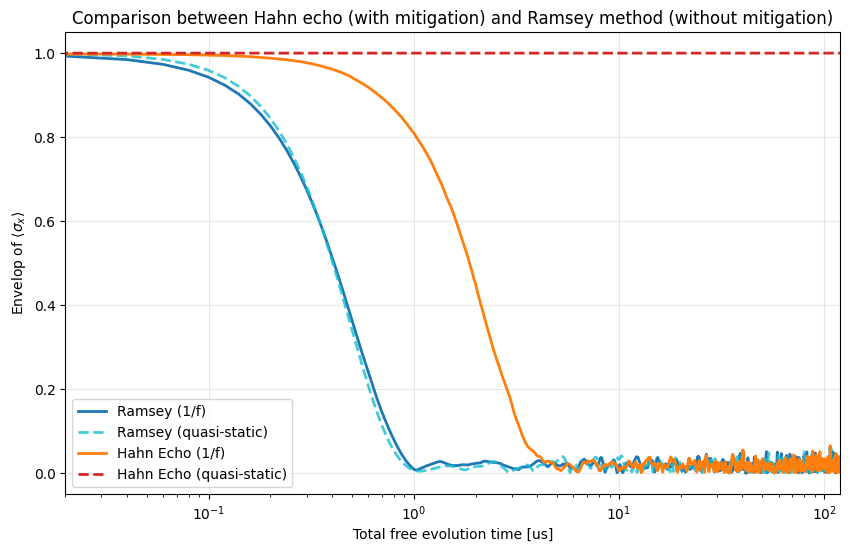

In [14]:
# Affichage Comparatif
plt.figure(figsize=(10, 6))

# Courbes de Ramsey (Décroissance rapide T2*)
plt.plot(tlist_echo, np.abs(coherence_ramsey), label='Ramsey (1/f)', linewidth=2, color='tab:blue')
plt.plot(tlist_echo, np.abs(coherence_ramsey_quasistatic), label='Ramsey (quasi-static)', linewidth=2, linestyle='--', color='tab:cyan', alpha=0.8)

# Courbes d'Echo (Correction d'erreur)
plt.plot(tlist_echo_half, np.abs(coherence_echo), label='Hahn Echo (1/f)', linewidth=2, color='tab:orange')
plt.plot(tlist_echo_half, np.abs(coherence_echo_quasistatic), label='Hahn Echo (quasi-static)', linewidth=2, linestyle='--', color='tab:red')

plt.xlabel('Total free evolution time [us]')
plt.ylabel('Envelop of '+r'$\langle \sigma_x \rangle$')
plt.title('Comparison between Hahn echo (with mitigation) and Ramsey method (without mitigation)')
plt.xscale('log')
plt.xlim(dt_echo, T_max_echo)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

two-source model : T2* = 503 ns, T2_echo = 38.9 us, ratio = 77


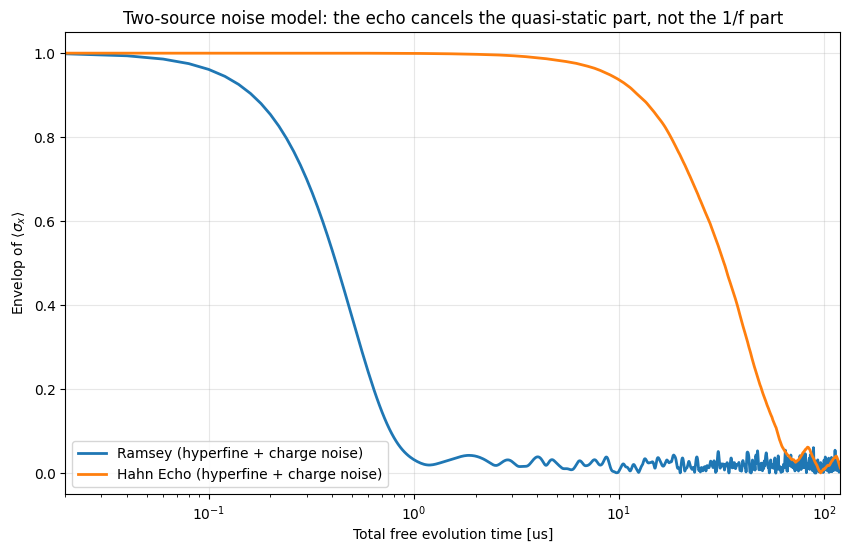

In [15]:
# Why one 1/f source cannot reproduce the factor ~80 of the IEDM paper.
# For pure 1/f the echo gain is only LOGARITHMIC: Ramsey collects the whole low frequency band down to
# f_min, the echo filter cuts everything below ~1/t, and what survives gives
#   T2_echo/T2* ~ sqrt( ln(1/(f_min*T2*)) / ln(2) )
# which is ~4-6 here, i.e. what I measure. So the factor 80 needs TWO sources, which is exactly what
# the paper says: decoherence is limited by hyperfine interaction at low frequency (nearly frozen on
# the experiment timescale -> cancelled almost exactly by the echo), while the echo brings the qubit
# into an electrical noise limited regime (genuine 1/f charge noise -> barely suppressed).
# So: a large quasi-static part sets T2*, a small 1/f part sets T2_echo.

frac_1f = 0.003   # fraction of the total variance carried by the 1/f (charge noise) component
sigma_mix = np.sqrt(1.0 - frac_1f) * sigma_noise      #hyperfine, quasi-static
S0_mix = frac_1f * S0_echo                            #charge noise, 1/f

phases_mix = (onef_phases(tlist_echo, N_samples, S0_mix, detuning=0.0, t_m=t_m_echo)
              + quasistatic_phases(tlist_echo, N_samples, sigma_mix, detuning=0.0))

coherence_ramsey_mix = np.exp(-1j * phases_mix).mean(axis=0)
coherence_echo_mix = np.exp(-1j * echo_phases(phases_mix)).mean(axis=0)

T2_mix = fit_T2_gaussian(tlist_echo, np.abs(coherence_ramsey_mix))
T2_echo_mix = fit_T2_gaussian(tlist_echo_half, np.abs(coherence_echo_mix))
print(f"two-source model : T2* = {T2_mix*1e3:.0f} ns, T2_echo = {T2_echo_mix:.1f} us, ratio = {T2_echo_mix/T2_mix:.0f}")

plt.figure(figsize=(10, 6))
plt.plot(tlist_echo, np.abs(coherence_ramsey_mix), label='Ramsey (hyperfine + charge noise)', linewidth=2, color='tab:blue')
plt.plot(tlist_echo_half, np.abs(coherence_echo_mix), label='Hahn Echo (hyperfine + charge noise)', linewidth=2, color='tab:orange')
plt.xlabel('Total free evolution time [us]')
plt.ylabel('Envelop of '+r'$\langle \sigma_x \rangle$')
plt.title('Two-source noise model: the echo cancels the quasi-static part, not the 1/f part')
plt.xscale('log')
plt.xlim(dt_echo, T_max_echo)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()